In [ ]:
using GLPK, JuMP, Plots

model = Model(GLPK.Optimizer)
# alpha = 1.0; beta = 0.0   # only cost
alpha = 0.5; beta = 0.5   # balanced
# alpha = 0.2; beta = 0.8   # CO2-focused

N = 20      # amount timesteps
M = 3       # amount heat-sources
# 1 = Wärmepumpe        heat pump
# 2 = Biomassekessel    biomass boiler
# 3 = Gaskessel         gas boiler

# je Heizquelle
c = [25, 35, 80]         # COST              - €/MWh
s = [30, 40, 200]        # SUSTAINABILITY    - kg_CO2/MWh

m = [120, 150, 100]     # max. MW
# je Zeitpunkt      
"""Demand darf 370 nicht überschreiten"""
d = [370, 200, 230, 270, 300, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190]   # MW 
# Steigung - Steuerungsspontanität
k_heat = [60,30,100]        # max heat-up speed
k_cool = [60,30,100]        # max cool-down speed

#thermal storage
E_maxCharge = 60
E_maxDischarge = 60
E_max = 200
E_start = 100
eff_charge = 0.9
eff_discharge = 0.9

@variable(model, E[1:N] >= 0)
@variable(model, charge[1:N] >= 0)
@variable(model, discharge[1:N] >= 0)

### ---
@variable(model, storageReserve[1:N] >= 0)

@variable(model, x[1:3,1:N] >= 0)

# KOSTEN minimieren
@objective( model, Min, alpha * sum( sum(x[j,t]*c[j] for t=1:N) for j=1:M) + 
                        beta * sum( sum(x[j,t]*s[j] for t=1:N) for j=1:M))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model, [j=1:M,t=1:N], x[j,t] <= m[j])
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model, [j=1:M, t=2:N],  x[j,t] - x[j,t-1] <= k_heat[j])
@constraint(model, [j=1:M, t=2:N],  x[j,t-1] - x[j,t] <= k_cool[j])

# SPEICHER
@constraint(model, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model, [t=1:N], sum( x[i,t] for i=1:M) + discharge[t] == d[t] + charge[t])      # heat-equality

@constraint(model, [t=2:N], E[t] == E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model, E[N] == E_start)

###
@constraint(model, [t=1:N], storageReserve[t] <= E_maxDischarge)
@constraint(model, [t=1:N],storageReserve[t] <= E[t] * eff_discharge)
@constraint(model, [t=1:N], sum(x[j,t] for j=1:M) + storageReserve[t] >= 1.05 * d[t])

optimize!(model)

println("Solver status: ", termination_status(model))
println("Solution status: ", primal_status(model))
## Printing the solution
println("Objective value = ", objective_value(model)) 

for j=1:M
    for i=1:N
        print(value(x[j,i]),"\t")
    end
    println(".")
end

cost = 0
CO2 = 0

for j=1:M
    for i=1:N
        cost += value(x[j,i])*c[j]
        CO2 += value(x[j,i])*s[j]
    end

end
println("Cost in €: ",cost)
println("CO2 in Kg: ", CO2)

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 182071.00296861745
120.0	120.0	120.0	120.0	120.0	120.0	120.0	120.0	120.0	120.00000000000006	119.99999999999994	59.999999999999986	0.0	60.0	120.0	120.0	120.0	120.0	120.0	120.0	.
150.0	120.0	120.0	150.0	150.0	150.0	126.48148148148147	141.2345679012346	149.99999999999997	130.0	114.6913580246914	90.0	60.0	90.0	120.0	150.0	120.0	106.71755725190837	136.71755725190837	106.71755725190837	.
64.25000000000003	0.0	0.0	0.0	0.0	0.0	0.0	0.0	58.49999999999999	0.0	0.0	-1.7763568394002505e-14	0.0	73.5	14.999999999999986	0.0	0.0	0.0	0.0	0.0	.
Cost in €: 157789.60277070964
CO2 in Kg: 206352.40316652527


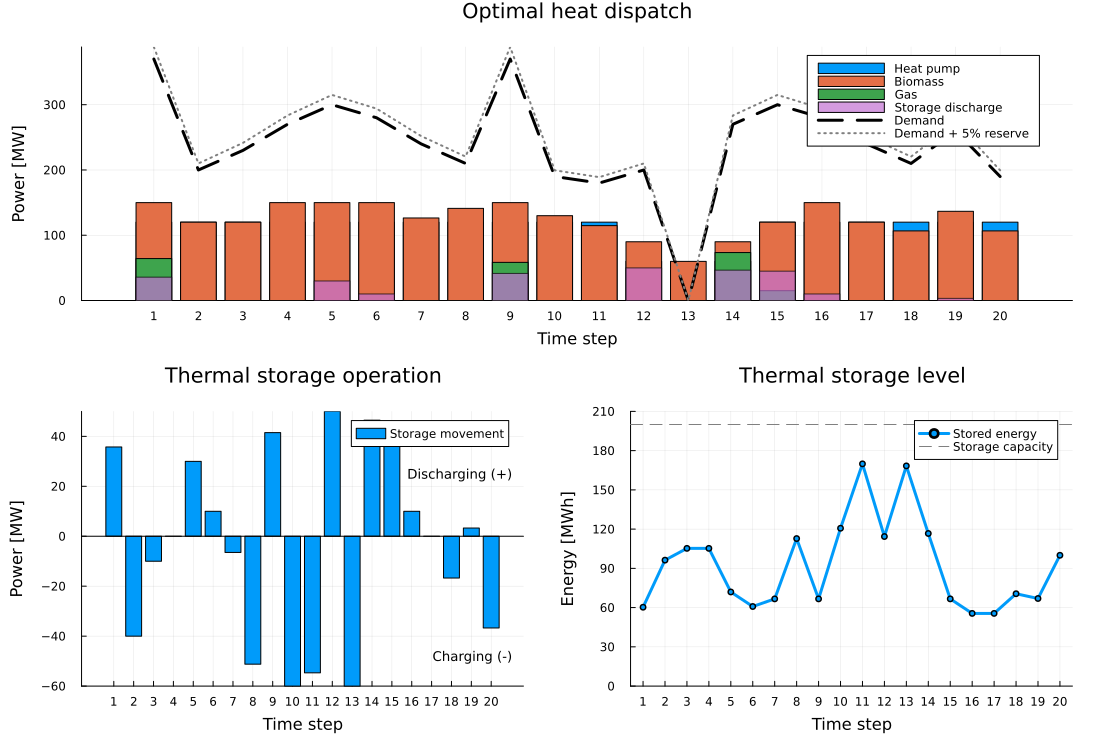

In [32]:
# ============================================================
# PLOTTING
# ============================================================

x_result = value.(x)

hp      = x_result[1,:]
biomass = x_result[2,:]
gas     = x_result[3,:]

charge_result    = value.(charge)
discharge_result = value.(discharge)
storage_level    = value.(E)

# positiv = Speicher liefert Wärme
# negativ = Speicher wird geladen
storage_movement = discharge_result .- charge_result

demand_105 = 1.05 .* d

# ------------------------------------------------------------
# 1. HEAT DISPATCH
# ------------------------------------------------------------

generation = hcat(hp, biomass, gas)

p1 = bar(
    1:N,
    generation,
    bar_position = :stack,
    labels = ["Heat pump" "Biomass" "Gas"],
    xlabel = "Time step",
    ylabel = "Power [MW]",
    title = "Optimal heat dispatch",
    xticks = 1:N,
    grid = true,
    legend = :topright,
    size = (1000,400)
)

# tatsächlich aus Speicher abgegebene Wärme
bar!(
    p1,
    1:N,
    discharge_result,
    bottom = hp .+ biomass .+ gas,
    label = "Storage discharge",
    alpha = 0.7
)

plot!(
    p1,
    1:N,
    d,
    label = "Demand",
    linewidth = 3,
    linestyle = :dash,
    color = :black
)

plot!(
    p1,
    1:N,
    demand_105,
    label = "Demand + 5% reserve",
    linewidth = 2,
    linestyle = :dot,
    color = :gray
)

# 2. STORAGE CHARGING / DISCHARGING
p2 = bar(
    1:N,
    storage_movement,
    label = "Storage movement",
    xlabel = "Time step",
    ylabel = "Power [MW]",
    title = "Thermal storage operation",
    xticks = 1:N,
    grid = true,
    legend = :topright
)

hline!(
    p2,
    [0],
    color = :black,
    linewidth = 1,
    label = ""
)

annotate!(
    p2,
    N+1,
    maximum(storage_movement)*0.5,
    text("Discharging (+)", 9, :right)
)

annotate!(
    p2,
    N+1,
    minimum(storage_movement)*0.8,
    text("Charging (-)", 9, :right)
)

# 3. STORAGE ENERGY LEVEL
p3 = plot(
    1:N,
    storage_level,
    label = "Stored energy",
    xlabel = "Time step",
    ylabel = "Energy [MWh]",
    title = "Thermal storage level",
    linewidth = 3,
    marker = :circle,
    markersize = 3,
    xticks = 1:N,
    ylim = (0, E_max * 1.05),
    grid = true,
    legend = :topright
)

# maximum storage capacity
hline!(
    p3,
    [E_max],
    label = "Storage capacity",
    linestyle = :dash,
    color = :gray
)

# COMBINE
p = plot(
    p1,
    p2,
    p3,
    layout = @layout([a{0.48h}; b c]),
    size = (1100,750),
    margin = 5Plots.mm
)

display(p)

In [33]:
######################################
# TODO:
# - kapazitäten optimieren


INTERPRET THE TWO GRAPHS, AS FOLLOWS:
MovementStorage > 0 <=> storage discharges <=> Energy decreasing
MovementStorage < 0 <=> storage charges  <=> Energy increasing

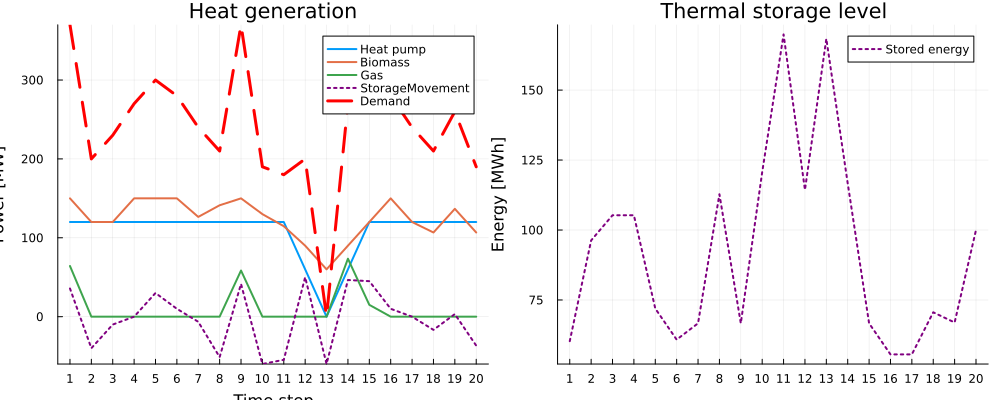

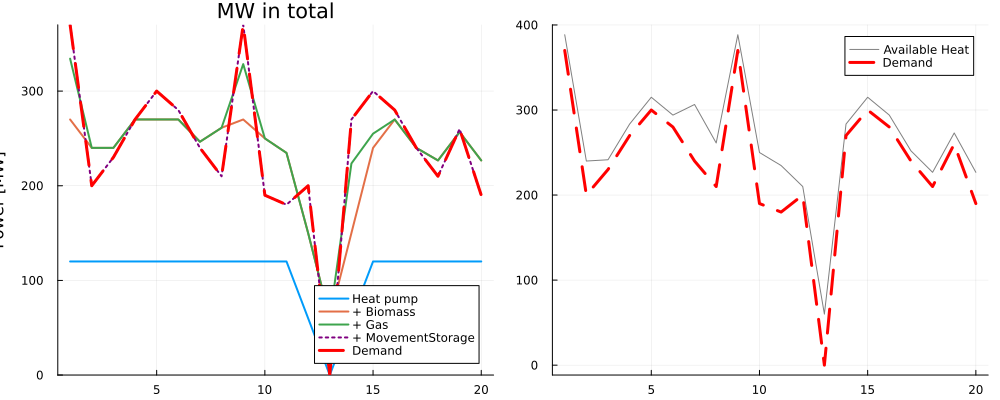

In [34]:
MovementStorage = value.(discharge) - value.(charge)
InStorage   = value.(E)
StoreReserve = value.(storageReserve)
ymax = maximum(d)
ymin = minimum([minimum(MovementStorage),0])

p_power = plot(1:N,[value.(x[j,:]) for j in 1:3],labels=["Heat pump" "Biomass" "Gas"],xlabel="Time step",ylabel="Power [MW]",lw=2,title="Heat generation",ylim=(ymin,ymax), xticks=1:N, grid=true)
plot!(p_power, 1:N, MovementStorage,label="StorageMovement",lw=2,linestyle=:dot,color=:purple)
plot!(p_power, 1:N, d,label="Demand",lw=3,linestyle=:dash,color=:red)

p_storage = plot(1:N,InStorage,label="Stored energy",ylabel="Energy [MWh]",lw=2,title="Thermal storage level",linestyle=:dot,color=:purple, xticks=1:N,grid=true)   #,ylim=(ymin,ymax)

annotate!(p_storage, 2, 300,
    text("",
         9, :left)
)
p = plot(p_power,p_storage,layout=(1,2),size=(1000,400))
print("INTERPRET THE TWO GRAPHS, AS FOLLOWS:
MovementStorage > 0 <=> storage discharges <=> Energy decreasing
MovementStorage < 0 <=> storage charges  <=> Energy increasing"
)
display(p)


x_result = value.(x)

hp  = x_result[1,:]
bio = hp .+ x_result[2,:]
gas = bio .+ x_result[3,:]
total = gas .+ MovementStorage[:]
totalAvailability = gas .+ StoreReserve[:]
# tes = gas .+ x_result[4,:]

p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total",ylim=(0,ymax))
plot!(p1, 1:N, bio, label="+ Biomass", lw=2)
plot!(p1, 1:N, gas, label="+ Gas", lw=2)
plot!(p1, 1:N, total, label="+ MovementStorage", lw=2, linestyle=:dot,color=:purple)
# plot!(p1, 1:N, totalAvailability, label="Available Heat",lw=1,color=:grey)
plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash, color=:red)

# xlabel!(p1, "Time step")
ylabel!(p1, "Power [MW]")

p2 = plot(1:N, totalAvailability, label="Available Heat",lw=1,color=:grey)
plot!(p2,1:N,d,label="Demand",lw=3, linestyle=:dash,color=:red)
p12 = plot(p1,p2,layout=(1,2),size=(1000,400))

display(p12)